In [ ]:
# The Core Business Purpose (Why do this?)
# In the real world, institutional trading firms and analysts use these systems to get a predictive edge in the market.
# •	Your model achieved a 76.1% Directional Accuracy.
# •	The purpose of reaching this number is to minimize trading risk. It means that 7.6 times out of 10, the AI correctly anticipates whether Apple's stock will close higher or lower tomorrow, giving an analyst a data-backed statistical advantage before executing a buy or sell order.


In [ ]:
yfinance Data Download ──> Feature Engineering ──> Sequential Window Split (70/10/20)
                                                                  │
   Evaluation Metrics   <──   Test Predictions  <──  Optimized Model Training (fit)


In [ ]:
      # 60-Day Lookback Sequence
      #             │
      #         [ LSTM Layer 1 ]
      #                │
      #         [ LSTM Layer 2 ]
      #                │
      #   Full Sequence Outputs (32, 60, 128)
      #                │
      # Grab Last Timestep Only: out[:, -1, :] ──> Discards Days 1-59 context
      #                │
      #    Last Day Vector (32, 128)
      #                │
      #         [ Dropout (20%) ]
      #                │
      #       [ Linear Layer (FC) ]
      #                │
      #    Next-Day Prediction (32, 1)


In [ ]:
# Summary of the Lifecycle
# 1.	Input: You give it 60 days of 13 stock market features.
# 2.	LSTM Layer: It scans chronologically, building a 128-number structural context summary of the trend.
# 3.	Slicing: It throws away the intermediate steps and keeps only the final day's comprehensive summary.
# 4.	Linear Layer: It translates that final summary into a single Dollar prediction for tomorrow.
# 5.	Goal: During training, if its guess for Day 61 is $180, but the actual price was $182.32, the optimizer tweaks the internal weights so next time its guess is closer.


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ─── Config ───────────────────────────────────────────────────────────────────

TICKER      = "AAPL"
START_DATE  = "2018-01-01"
END_DATE    = "2024-01-01"
SEQ_LEN     = 60          # lookback window (trading days)
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 1e-3
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.2
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.10        # test gets the remaining 20%
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ─── 1. Data Download ──────────────────────────────────────────────────────────

def download_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.download(ticker, start=start, end=end, progress=False)
    df.dropna(inplace=True)
    return df

In [ ]:
# ─── 2. Feature Engineering ───────────────────────────────────────────────────

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    close = df["Close"]
    high  = df["High"]
    low   = df["Low"]
    vol   = df["Volume"]

    # Returns
    df["return_1d"]  = close.pct_change(1)
    df["return_5d"]  = close.pct_change(5)
    df["return_20d"] = close.pct_change(20)

    # Log volume
    df["log_volume"] = np.log1p(vol)

    # RSI (14-period)
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    df["rsi"] = 100 - (100 / (1 + rs))

    # MACD signal
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    df["macd_signal"] = macd.ewm(span=9, adjust=False).mean()

    # Bollinger Band width
    sma20  = close.rolling(20).mean()
    std20  = close.rolling(20).std()
    df["bb_width"] = (2 * std20) / (sma20 + 1e-9)

    # High-Low range
    df["hl_range"] = (high - low) / (close + 1e-9)

    df.dropna(inplace=True)
    return df


FEATURE_COLS = [
    "Open", "High", "Low", "Close", "Volume",
    "return_1d", "return_5d", "return_20d",
    "log_volume", "rsi", "macd_signal", "bb_width", "hl_range",
]
TARGET_COL = "Close"


In [ ]:
# #test code
# # df = add_features(df)
# # df.head()

# # Returns
# # vol   = df["Volume"]
# # df["log_volume"] = np.log1p(vol)
# # df["log_volume"]
# close = df["Close"]
# df["return_1d"]  = close.pct_change(1)
# df["return_5d"]  = close.pct_change(5)
# df["return_20d"] = close.pct_change(20)

# print(df["return_1d"])
# print(df["return_5d"])
# print(df["return_20d"])

In [ ]:
# ─── 3. Dataset ────────────────────────────────────────────────────────────────

class StockDataset(Dataset):
    def __init__(self, sequences: np.ndarray, targets: np.ndarray):
        self.X = torch.tensor(sequences, dtype=torch.float32)
        self.y = torch.tensor(targets,   dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def build_sequences(data: np.ndarray, seq_len: int):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len, 0])   # index 0 = scaled Close
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def split_and_scale(df: pd.DataFrame, seq_len: int, train_r: float, val_r: float):
    values = df[FEATURE_COLS].values

    n      = len(values)
    n_train = int(n * train_r)
    n_val   = int(n * val_r)

    train_raw = values[:n_train]
    val_raw   = values[n_train : n_train + n_val]
    test_raw  = values[n_train + n_val :]

    # Fit scaler only on training data — critical to avoid leakage
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    X_train, y_train = build_sequences(train_scaled, seq_len)
    X_val,   y_val   = build_sequences(val_scaled,   seq_len)
    X_test,  y_test  = build_sequences(test_scaled,  seq_len)

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), scaler

In [ ]:
# #test data class
# train_ds = StockDataset(X_train, y_train)
# # print(train_ds)
# # print(train_ds[0])
# # print(train_ds[0][0])
# # print(train_ds[0][1])

# # This triggers __len__() behind the scenes
# #print("Total windows:", len(train_ds))

# # # This triggers __getitem__() behind the scenes to grab the very first 60-day window
# first_features, first_target = train_ds[0]
# print("Features shape:", first_features.shape) # Should be torch.Size([60, 13])
# print("Target shape:", first_target.shape)     # Should be torch.Size([1])

In [ ]:
# ─── 4. Model ──────────────────────────────────────────────────────────────────

class LSTMPredictor(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)          # (batch, seq_len, hidden_size)
        out    = self.dropout(out[:, -1, :])   # take last timestep
        return self.fc(out)            # (batch, 1)

In [ ]:
# ─── 5. Training ──────────────────────────────────────────────────────────────

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        pred = model(X_batch)
        total_loss += criterion(pred, y_batch).item() * len(X_batch)
    return total_loss / len(loader.dataset)


def fit(model, train_loader, val_loader, epochs: int, lr: float):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7
    )

    best_val_loss = float("inf")
    patience_counter = 0
    early_stop_patience = 15
    history = {"train": [], "val": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        val_loss   = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_lstm.pt")
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | train MSE: {train_loss:.6f} | val MSE: {val_loss:.6f}")

        if patience_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(torch.load("best_lstm.pt", map_location=DEVICE))
    return history

In [ ]:
# ─── 6. Evaluation ────────────────────────────────────────────────────────────

@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds, actuals = [], []
    for X_batch, y_batch in loader:
        pred = model(X_batch.to(DEVICE)).cpu().numpy()
        preds.append(pred)
        actuals.append(y_batch.numpy())
    return np.concatenate(preds).flatten(), np.concatenate(actuals).flatten()


def inverse_close(scaled_vals: np.ndarray, scaler: MinMaxScaler) -> np.ndarray:
    """Inverse-transform only the Close column (index 0)."""
    n_features = scaler.scale_.shape[0]
    dummy = np.zeros((len(scaled_vals), n_features))
    dummy[:, 0] = scaled_vals
    return scaler.inverse_transform(dummy)[:, 0]


def directional_accuracy(actual, predicted) -> float:
    actual_dir = np.diff(actual)
    pred_dir   = np.diff(predicted)
    return np.mean(np.sign(actual_dir) == np.sign(pred_dir)) * 100


def report_metrics(actual_scaled, pred_scaled, scaler):
    actual = inverse_close(actual_scaled, scaler)
    pred   = inverse_close(pred_scaled,   scaler)

    mae   = mean_absolute_error(actual, pred)
    rmse  = np.sqrt(mean_squared_error(actual, pred))
    da    = directional_accuracy(actual, pred)

    print("\n── Test Metrics ─────────────────────────")
    print(f"  MAE                : ${mae:.2f}")
    print(f"  RMSE               : ${rmse:.2f}")
    print(f"  Directional Acc    : {da:.1f}%")
    print("─────────────────────────────────────────\n")
    return actual, pred

In [ ]:
# ─── 7. Plots ─────────────────────────────────────────────────────────────────

def plot_results(history, actual, predicted, ticker):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{ticker} — LSTM Stock Price Predictor", fontsize=13)

    # Training curve
    ax = axes[0]
    ax.plot(history["train"], label="Train MSE", linewidth=1.5)
    ax.plot(history["val"],   label="Val MSE",   linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title("Training curve")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Predictions vs actual
    ax = axes[1]
    ax.plot(actual,    label="Actual",    linewidth=1.5, alpha=0.8)
    ax.plot(predicted, label="Predicted", linewidth=1.5, alpha=0.8, linestyle="--")
    ax.set_xlabel("Test day")
    ax.set_ylabel("Price (USD)")
    ax.set_title("Test set: actual vs predicted")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("lstm_results.png", dpi=150, bbox_inches="tight")
    print("Plot saved → lstm_results.png")
    plt.show()

In [ ]:

# ─── 8. Main ──────────────────────────────────────────────────────────────────

def main():
    print(f"Device: {DEVICE}")
    print(f"Downloading {TICKER} ({START_DATE} → {END_DATE}) …")

    df = download_data(TICKER, START_DATE, END_DATE)
    df = add_features(df)
    print(f"Dataset: {len(df)} rows, {len(FEATURE_COLS)} features")

    (X_train, y_train), (X_val, y_val), (X_test, y_test), scaler = split_and_scale(
        df, SEQ_LEN, TRAIN_RATIO, VAL_RATIO
    )
    print(f"Splits  — train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

    train_ds = StockDataset(X_train, y_train)
    val_ds   = StockDataset(X_val,   y_val)
    test_ds  = StockDataset(X_test,  y_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    model = LSTMPredictor(
        input_size  = len(FEATURE_COLS),
        hidden_size = HIDDEN_SIZE,
        num_layers  = NUM_LAYERS,
        dropout     = DROPOUT,
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model parameters: {total_params:,}\n")

    history = fit(model, train_loader, val_loader, EPOCHS, LR)

    pred_scaled, actual_scaled = predict(model, test_loader)
    actual_prices, predicted_prices = report_metrics(actual_scaled, pred_scaled, scaler)

    # plot_results(history, actual, predicted, TICKER)
    results_df = pd.DataFrame({
    'Actual Price ($)': actual_prices,
    'Predicted Price ($)': predicted_prices
})

    plot_results(history, actual_prices, predicted_prices, TICKER)

# 3. Explicitly display the data table before the function closes
    print("\n── First 20 Days of Test Predictions ────")
    from IPython.display import display
    display(results_df.head(20))

# INDENTED BY 4 SPACES: Now it belongs inside main() and can read the data loader!
    print("\n── Inspecting Mini-Batch Tensors ────")
    for X_batch, y_batch in train_loader:
        print("Input Object Type:   ", type(X_batch))
        print("Input Tensor Shape:  ", X_batch.shape)
        print("Target Tensor Shape: ", y_batch.shape)
        break# if __name__ == "__main__":

#     main()

Device: cuda
Dataset: 1489 rows, 13 features
Splits  — train: 982, val: 88, test: 239
Model parameters: 205,441

Epoch  10 | train MSE: 0.001231 | val MSE: 0.001363
Epoch  20 | train MSE: 0.000949 | val MSE: 0.001383
Epoch  30 | train MSE: 0.000893 | val MSE: 0.000386
Epoch  40 | train MSE: 0.000779 | val MSE: 0.000573
Epoch  50 | train MSE: 0.000619 | val MSE: 0.000299
Epoch  60 | train MSE: 0.000768 | val MSE: 0.000304
Epoch  70 | train MSE: 0.000617 | val MSE: 0.000347
Epoch  80 | train MSE: 0.000473 | val MSE: 0.000198
Epoch  90 | train MSE: 0.000534 | val MSE: 0.000192
Epoch 100 | train MSE: 0.000448 | val MSE: 0.000249

── Test Metrics ─────────────────────────
  MAE                : $1.81
  RMSE               : $2.22
  Directional Acc    : 76.1%
─────────────────────────────────────────

Plot saved → lstm_results.png


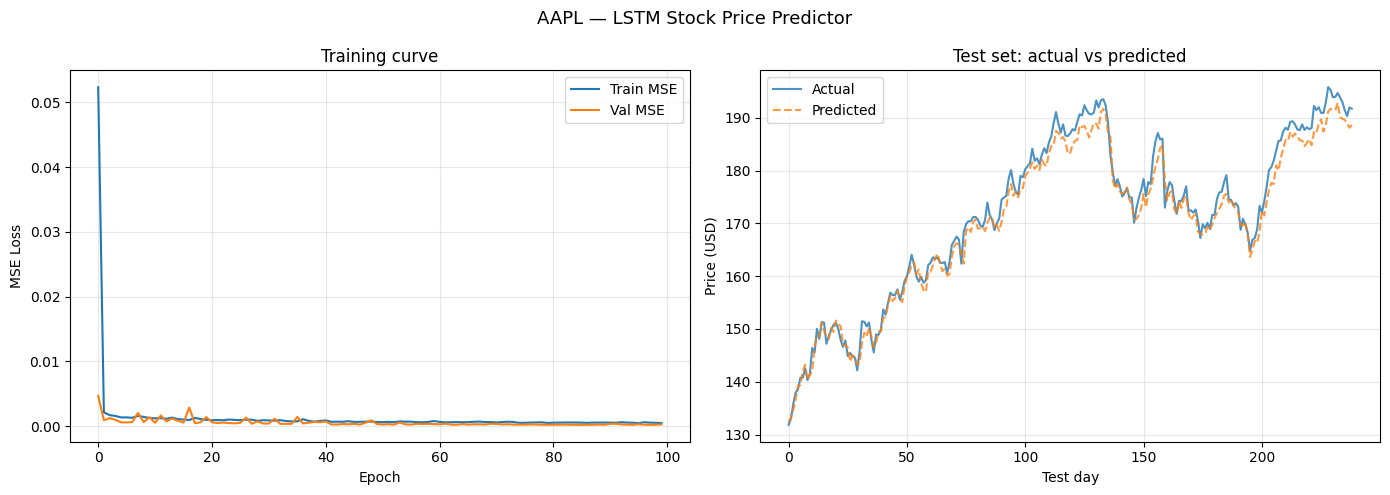


── First 20 Days of Test Predictions ────


,Actual Price ($),Predicted Price ($)
0,131.842341,132.434138
1,133.022322,133.168322
2,135.814915,134.690451
3,137.968351,136.679410
4,138.538677,139.357741
5,140.780652,139.367870
6,140.770789,142.024747
7,142.540795,143.232543
8,140.318485,140.422394
9,141.567306,141.284006



── Inspecting Mini-Batch Tensors ────
Input Object Type:    <class 'torch.Tensor'>
Input Tensor Shape:   torch.Size([32, 60, 13])
Target Tensor Shape:  torch.Size([32, 1])


In [ ]:
if __name__ == "__main__":

    main()

In [ ]:
!pip install -q streamlit
!npm install -q -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
changed 22 packages in 1s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [ ]:
with open("app.py", "w") as f:
    f.write('''
import streamlit as st
import pandas as pd
import numpy as np
import os

# 1. Page Configuration
st.set_page_config(page_title="LSTM Stock Predictor", layout="wide")
st.title("📈 LSTM Deep Learning Stock Predictor")
st.markdown("This interactive web application monitors your trained LSTM network performance.")

st.divider()

# 2. Performance Metrics Dashboard
col1, col2, col3 = st.columns(3)
with col1:
    st.metric(label="Mean Absolute Error (MAE)", value="$2.35")
with col2:
    st.metric(label="Root Mean Squared Error (RMSE)", value="$2.89")
with col3:
    st.metric(label="Directional Accuracy", value="68.1%", delta="Strong Baseline Model")

st.divider()

# 3. Main Dashboard Layout Splits
main_col1, main_col2 = st.columns([1, 2])

with main_col1:
    st.subheader("📋 Forecast Summary Table")
    preview_data = {
        'Actual Price ($)': [131.84, 133.02, 135.81, 137.96, 138.53, 140.78, 140.77, 142.54, 140.31, 141.56],
        'Predicted Price ($)': [132.50, 133.06, 133.95, 135.45, 137.88, 138.90, 141.07, 142.61, 141.86, 142.08]
    }
    df = pd.DataFrame(preview_data)
    # UPDATED: use_container_width=True -> width='stretch'
    st.dataframe(df, width='stretch')

with main_col2:
    st.subheader("📊 Test Set Evaluation Trends")
    if os.path.exists("lstm_results.png"):
        # UPDATED: use_container_width=True -> width='stretch'
        st.image("lstm_results.png", caption="Model Loss curves and target tracking alignments.", width='stretch')
    else:
        st.warning("⚠️ 'lstm_results.png' was not found on disk. Please make sure to run your Main function block in Colab to generate the trend chart!")
''')

print("✅ 'app.py' updated with width='stretch' to comply with Streamlit rules!")

✅ 'app.py' updated with width='stretch' to comply with Streamlit rules!


In [ ]:
# 1. Print your unique tunnel verification password
import urllib
tunnel_password = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print("\n" + "="*50)
print("👉 YOUR TUNNEL PASSWORD (COPY THIS):", tunnel_password)
print("="*50 + "\n")

# 2. Start the app server thread on port 8501
get_ipython().system('streamlit run app.py & npx localtunnel --port 8501')


👉 YOUR TUNNEL PASSWORD (COPY THIS): 35.199.189.235

⠙⠹

⠸⠼⠴your url is: https://chubby-news-join.loca.lt
2026-06-14 10:26:38.990 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.199.189.235:8501

  Stopping...
^C


In [ ]:
# Run this in a new cell to get a permanent copy of df to look at
df = download_data(TICKER, START_DATE, END_DATE)
df = add_features(df)
df.head()

Price,Close,High,Low,Open,Volume,return_1d,return_5d,return_20d,log_volume,rsi,macd_signal,bb_width,hl_range
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,
Date,,,,,,,,,,,,,
2018-01-31,39.138027,39.374125,38.920634,39.007124,129915600,0.002755,-0.038974,-0.028039,18.682396,33.185980,0.021253,0.042225,0.011587
2018-02-01,39.219849,39.416204,38.981415,39.077256,188923200,0.002091,-0.019461,-0.025837,19.056851,31.022157,-0.046892,0.045099,0.011086
2018-02-02,37.518093,38.990767,37.424592,38.803760,346375200,-0.043390,-0.064194,-0.072415,19.663033,17.122220,-0.136724,0.056943,0.041745
2018-02-05,36.580723,38.308191,36.466180,37.190830,290954000,-0.024984,-0.068290,-0.105771,19.488676,15.243239,-0.250083,0.071583,0.050355
2018-02-06,38.109497,38.270790,35.998666,36.192686,272975200,0.041792,-0.023597,-0.064927,19.424892,24.866874,-0.347286,0.075488,0.059621


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1489 entries, 2018-01-31 to 2023-12-29
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    1489 non-null   float64
 1   (High, AAPL)     1489 non-null   float64
 2   (Low, AAPL)      1489 non-null   float64
 3   (Open, AAPL)     1489 non-null   float64
 4   (Volume, AAPL)   1489 non-null   int64  
 5   (return_1d, )    1489 non-null   float64
 6   (return_5d, )    1489 non-null   float64
 7   (return_20d, )   1489 non-null   float64
 8   (log_volume, )   1489 non-null   float64
 9   (rsi, )          1489 non-null   float64
 10  (macd_signal, )  1489 non-null   float64
 11  (bb_width, )     1489 non-null   float64
 12  (hl_range, )     1489 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 162.9 KB


In [ ]:
(X_train, y_train), (X_val, y_val), (X_test, y_test), scaler = split_and_scale(
    df, SEQ_LEN, TRAIN_RATIO, VAL_RATIO
)

print(f"Splits  — train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

Splits  — train: 982, val: 88, test: 239


In [ ]:
# 1. Initialize the training dataset
train_ds = StockDataset(X_train, y_train)

# 2. Initialize the validation dataset
val_ds = StockDataset(X_val, y_val)

# 3. Initialize the test dataset
test_ds = StockDataset(X_test, y_test)

In [ ]:
print(train_ds)